In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../data/NF-UNSW-NB15-v3.csv")

## Drop irrelevant features 

In [3]:
id_cols = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT',
           'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS']

In [4]:
cat_cols = ['Attack'] 

In [5]:
df_cleaned = df.drop(columns=id_cols + cat_cols)

## Fill missing values with 0

In [6]:
df_cleaned = df_cleaned.fillna(0)

## Identify numerical features

In [7]:
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('Label')

## Compute Pearsons Correlation analysis

In [13]:
corr_with_label = df_cleaned[numerical_cols].corrwith(df_cleaned['Label'])

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [14]:
corr_with_label = corr_with_label.sort_values(ascending=False)

In [18]:
print("Top 10 features correlated with Label:")
print(corr_with_label.head(15))

Top 10 features correlated with Label:
MAX_TTL                       0.895037
MIN_TTL                       0.894973
DST_TO_SRC_IAT_AVG            0.232930
DST_TO_SRC_IAT_STDDEV         0.160004
SHORTEST_FLOW_PKT             0.142930
SRC_TO_DST_IAT_STDDEV         0.123937
PROTOCOL                      0.072654
SRC_TO_DST_IAT_MAX            0.066606
SRC_TO_DST_IAT_AVG            0.059844
DST_TO_SRC_IAT_MAX            0.056799
DNS_QUERY_TYPE                0.042063
DURATION_OUT                  0.041814
RETRANSMITTED_IN_BYTES        0.038568
IN_BYTES                      0.035360
FLOW_DURATION_MILLISECONDS    0.033922
dtype: float64


## Results plotted in heatmap

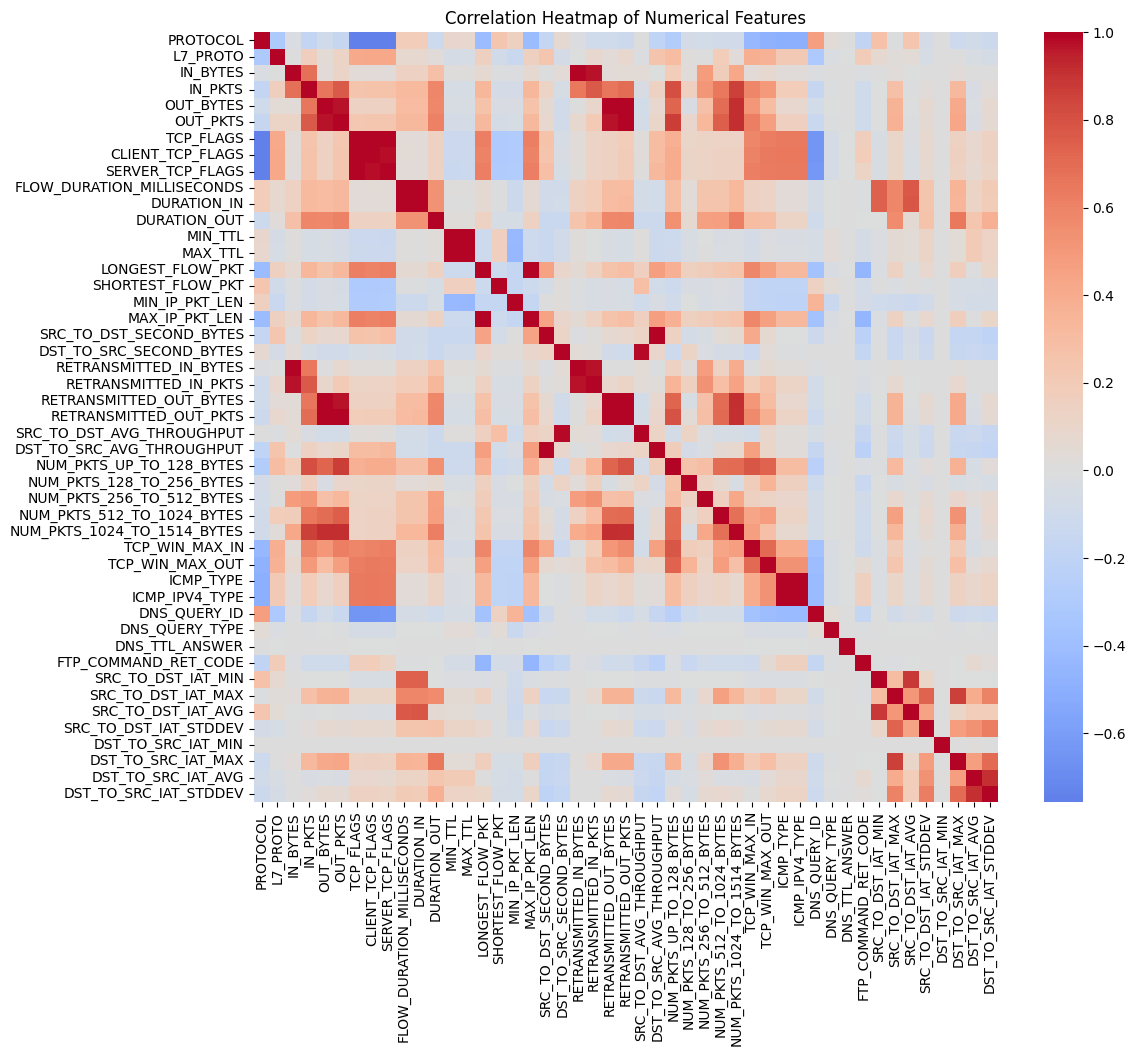

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned[numerical_cols].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()